In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [16]:
from arcgis.gis import GIS
gis = GIS("https://deldev.maps.arcgis.com", "demos_deldev", "DelDevs.1234")

In [3]:
from arcgis.features.summarize_data import join_features

In [4]:
item1 = gis.content.get('87b758aaf694473eb98ac12f3caba5fc')

<Item title:"Traffic Accident Locations" type:Feature Layer Collection owner:JohnsCreekGA>
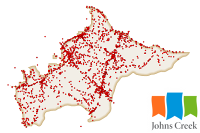

In [5]:
item1

In [6]:
item2 = gis.content.get('347e78364333497eb9cbb428b963015a')

<Item title:"parcels" type:Feature Layer Collection owner:demos_deldev>
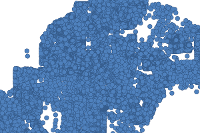

In [7]:
item2

In [8]:
test = join_features(target_layer=item2.layers[0],
                     join_layer=item1.layers[0],
                     spatial_relationship='withindistance',
                     spatial_relationship_distance=10,
                     spatial_relationship_distance_units='Meters',
                     context={"extent":{"xmin":-9377920.070348132,"ymin":4033028.758284475,"xmax":-9377465.031164061,"ymax":4033522.613146979,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

In [9]:
assert isinstance(test, FeatureCollection)
test

<FeatureCollection>

In [24]:
item3 = gis.content.get('774f52f47ad14a8389af0f851499e4d9')

In [ ]:
item3

In [29]:
from datetime import datetime
test = join_features(target_layer=item3.layers[0],
                     join_layer=item2.layers[0],
                     attribute_relationship=[{"targetField":"ParcelID","operator":"equal","joinField":"ParcelID"}],
                     join_operation='JoinOneToMany',
                     output_name='jattr' + str(datetime.now().microsecond),)
                     #context={"extent":{"xmin":-9377920.070348132,"ymin":4033028.758284475,"xmax":-9377465.031164061,"ymax":4033522.613146979,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

In [30]:
assert isinstance(test, Item)
test

<Item title:"jattr871793" type:Feature Layer Collection owner:demos_deldev>

In [ ]:
test.delete()

In [ ]:
test = join_features(target_layer=item2.layers[0],
                     join_layer=item1.layers[0],
                     future=True,
                     spatial_relationship='intersects',
                     context={"extent":{"xmin":-9377920.070348132,"ymin":4033028.758284475,"xmax":-9377465.031164061,"ymax":4033522.613146979,"spatialReference":{"wkid":102100,"latestWkid":3857}}})

In [ ]:
assert isinstance(test, GPJob)
test.result()

#### Test Overwrite

In [ ]:
from arcgis.gis import GIS
portal = GIS(profile="your_enterprise_profile", verify_cert=False,)
cougar_item = portal.content.get("71f20aa845f64f129a78303e6b5039c6")
if cougar_item:
    stream = cougar_item.layers[3]
    highway = cougar_item.layers[4]
    watershed = cougar_item.layers[2]
    test = join_features(target_layer=stream,
                     join_layer=highway,
                     output_name='join_features_to_overwrite',
                     spatial_relationship='intersects',)
    fl_to_overwrite = portal.content.get(test.id).layers[0]
    print(fl_to_overwrite)
    print(test.id)
    overwrite = join_features(target_layer=stream,
                     join_layer=watershed,
                     output_name=fl_to_overwrite,
                     spatial_relationship='intersects',
                     context={"overwrite":True},)
    overwrite.delete()